# Attention Head Analysis — Jailbreak Suffix Impact

**Research question**: When a DAN-style jailbreak suffix is appended to a harmful query, does the model’s internal attention mechanism change in a consistent, observable pattern?

**Data**: `outputs/attention_head_analysis/attention_results_clean.csv`  
500 query pairs × 32 transformer layers × 3 metrics, measured on Vicuna-7B.

---

## What are the Three Metrics?

Each transformer layer has 32 attention heads. For every head, we record the full `[seq_len × seq_len]` attention weight matrix (where `attn[i,j]` = how much token `i` attends to token `j`). We then compute three scalars per head and **average them across all 32 heads** to get one value per layer.

---

### Metric 1 — Attention Entropy

**Formula**: Flatten the attention matrix to a 1-D array, normalise it to sum to 1, then compute Shannon entropy:
```
entropy = −Σ p · log(p)
```

**Intuition**:  
Think of the attention matrix as a probability distribution over all `seq_len × seq_len` token-pair positions.  
- **Low entropy** → attention is **sharp / focused** on a few specific token pairs  
- **High entropy** → attention is **diffuse / scattered** across many positions

**What it means for jailbreaking**:  
If adding a jailbreak suffix causes entropy to rise, the model’s attention is becoming more diffuse — it’s no longer cleanly focusing on the semantic content of the query. It is uncertain about what to attend to.

---

### Metric 2 — Diagonal Mass

**Formula**: Average of the main diagonal of the attention matrix:
```
diag_mass = mean(attn[0,0], attn[1,1], ..., attn[n,n])
```

**Intuition**:  
`attn[i,i]` measures how much token `i` attends to **itself**. The diagonal is the self-attention backbone.
- **High diag_mass** → tokens mostly attend to themselves (stable, local processing)  
- **Low diag_mass** → tokens attend to **other** positions (cross-token influence is strong)

**What it means for jailbreaking**:  
A drop in diagonal mass means the jailbreak suffix is pulling attention **away from each token’s local self** and redistributing it to other (possibly jailbreak-injected) tokens. The suffix is actively redirecting what the model attends to.

---

### Metric 3 — Mean Attention Weight

**Formula**: Arithmetic mean of every entry in the attention matrix:
```
mean_weight = mean of entire [seq_len × seq_len] matrix
```

**Intuition**:  
Since each row of an attention matrix sums to 1, the mean of the whole matrix ≈ `1 / seq_len`. This is largely a **sequence-length proxy**.  
- **Longer sequence** → lower mean weight (the fixed probability mass is spread over more positions)  

**What it means for jailbreaking**:  
Mean weight drops when the DAN suffix is added, primarily because the sequence is longer. It confirms the structural change but is the least informative metric (mostly mechanical, not semantic).

---

## Structure of This Notebook

| Section | What it shows |
|---|---|
| **0** | Setup, data loading, metric arrays |
| **1** | Side-by-side heatmaps: Original vs DAN — the direct visual evidence |
| **2** | Delta heatmaps: consistent upward shift across all queries and layers |
| **3** | Layer-by-layer profile: how each metric changes layer-by-layer on average |
| **4** | Statistical confirmation: Wilcoxon tests + Cohen’s d effect sizes |
| **5** | Token length vs content: how much of the shift is explained by longer sequence |
| **6** | Summary findings |

---
## Section 0 — Setup & Data Loading

In [31]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# ── Colour palette ────────────────────────────────────────────────────────────
C_ORIG  = '#4C9BE8'   # blue   = original (no suffix)
C_DAN   = '#E63946'   # red    = DAN (with suffix)
C_DELTA = '#9B2226'   # dark-red = delta (DAN - original)

sns.set_theme(style='darkgrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'font.family': 'DejaVu Sans'})

N_LAYERS    = 32
LAYER_IDS   = list(range(N_LAYERS))
LAYER_LABELS = [f'L{i:02d}' for i in LAYER_IDS]

print('Libraries loaded OK')

Libraries loaded OK


In [32]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
CSV_PATH = os.path.normpath(os.path.join(
    NOTEBOOK_DIR, '..', 'outputs', 'attention_head_analysis', 'attention_results_clean.csv'))

print(f'Loading: {CSV_PATH}')
df = pd.read_csv(CSV_PATH)

# ── Build per-layer arrays (shape: 500 queries x 32 layers) ──────────────────
def get_arr(metric: str, condition: str) -> np.ndarray:
    """Return (n_queries, 32) array for one metric + condition pair."""
    cols = [f'l{i:02d}_{metric}_{condition}' for i in LAYER_IDS]
    return df[cols].values

# Raw values
ent_orig  = get_arr('entropy', 'original')   # (500, 32)
ent_dan   = get_arr('entropy', 'dan')
diag_orig = get_arr('diag',    'original')
diag_dan  = get_arr('diag',    'dan')
mean_orig = get_arr('mean',    'original')
mean_dan  = get_arr('mean',    'dan')

# Deltas  (DAN - original)
ent_delta  = ent_dan  - ent_orig
diag_delta = diag_dan - diag_orig
mean_delta = mean_dan - mean_orig

# Per-query total entropy shift (sum across all 32 layers)
tot_shift = ent_delta.sum(axis=1)    # (500,)

# Sort order: highest total entropy shift first
sort_idx = np.argsort(tot_shift)[::-1]

print(f'Shape: {ent_orig.shape}  (queries x layers)')
print(f'Null values: {df.isnull().sum().sum()}')
print(f'All 500 queries have positive entropy shift: {(tot_shift > 0).all()}')

Loading: d:\Study\Python\DS\llm\autodan-evo\outputs\attention_head_analysis\attention_results_clean.csv
Shape: (500, 32)  (queries x layers)
Null values: 0
All 500 queries have positive entropy shift: True


---
## Section 1 — Side-by-Side Heatmaps: Original vs DAN

These heatmaps are the **direct visual evidence**.

- Each **row** = one query (500 total, sorted by total entropy shift, highest first)
- Each **column** = one of the 32 transformer layers
- **Cell colour** = the value of the metric for that query-layer combination

Side-by-side comparison makes the shift immediately visible:
- Entropy: brighter (more red) in the DAN panel = attention is more diffuse with jailbreak
- Diagonal mass: darker (less) in the DAN panel = tokens stopped attending to themselves

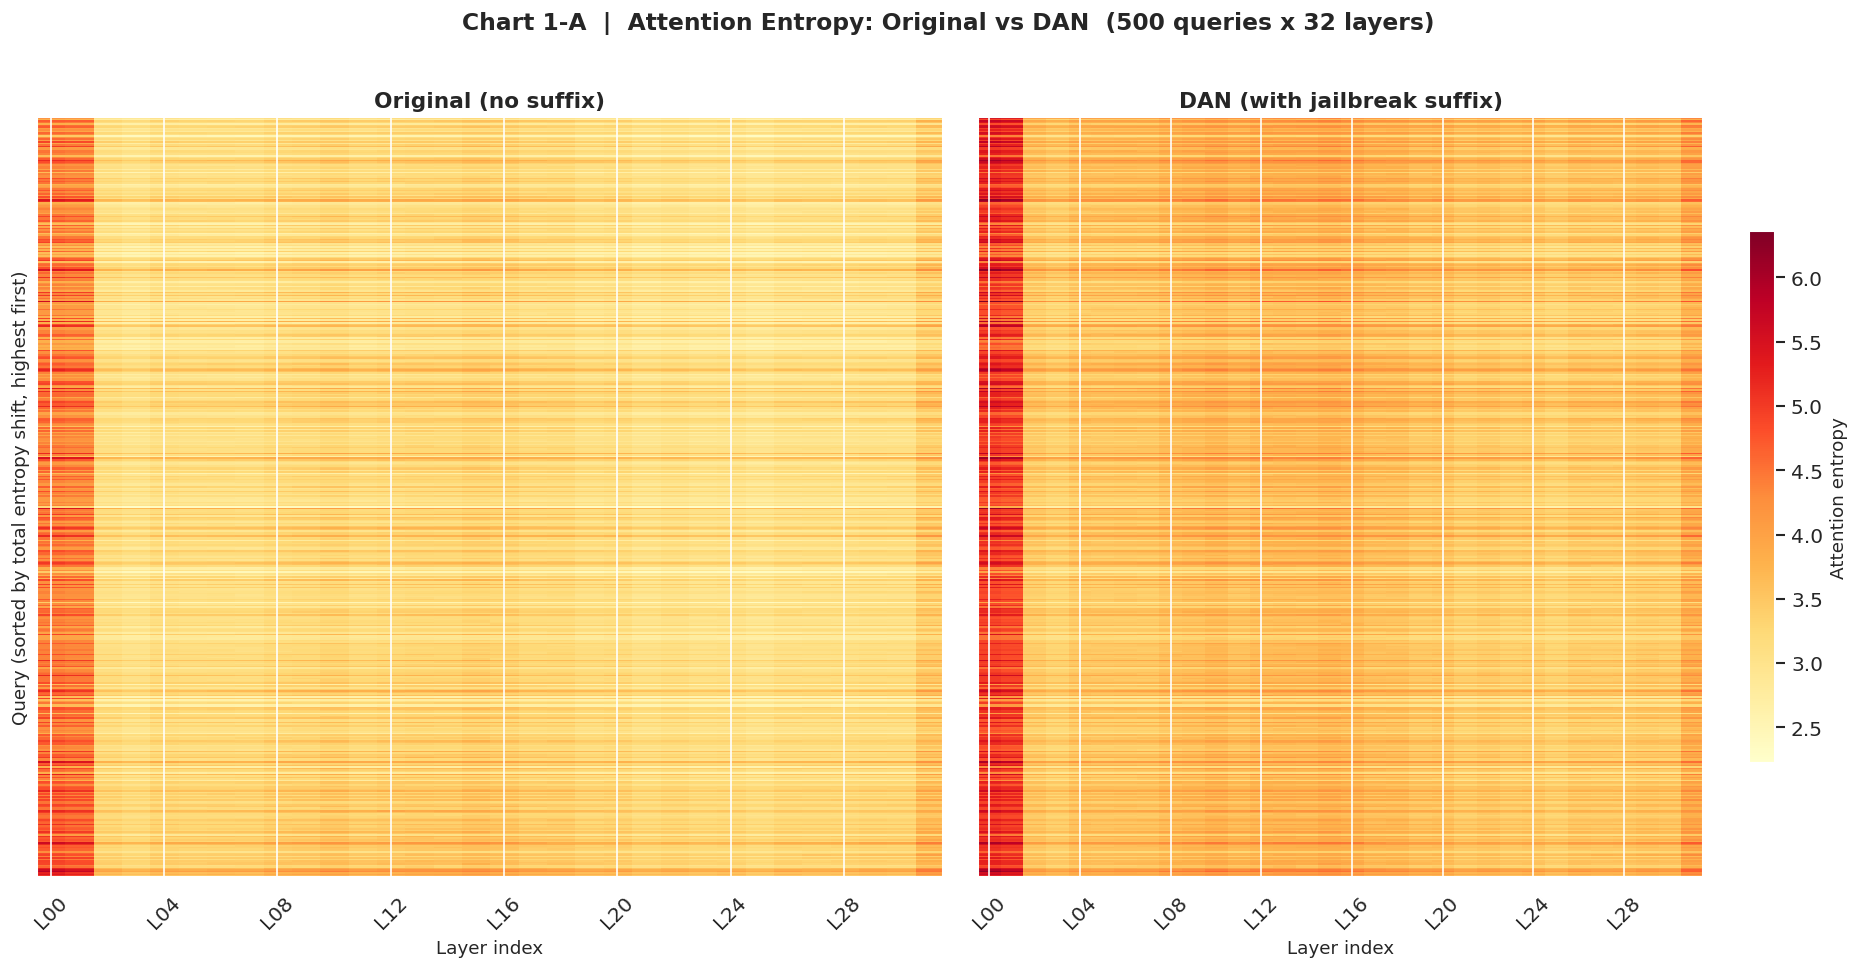

Reading this chart:
  Brighter / more yellow-red = higher entropy = more diffuse attention
  The DAN panel (right) is visibly brighter across all rows and columns.
  This means: the jailbreak suffix CONSISTENTLY raises attention entropy
  in every layer for every query.


In [33]:
# ── Chart 1-A: Entropy heatmap --- original (left) vs DAN (right) ─────────────
# Rows sorted by total entropy shift (most-affected queries at top)

E_orig_sorted = ent_orig[sort_idx, :]     # (500, 32)
E_dan_sorted  = ent_dan[sort_idx,  :]

vmin = min(E_orig_sorted.min(), E_dan_sorted.min())
vmax = max(E_orig_sorted.max(), E_dan_sorted.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for ax, data, title in zip(axes,
                            [E_orig_sorted, E_dan_sorted],
                            ['Original (no suffix)', 'DAN (with jailbreak suffix)']):
    im = ax.imshow(data, aspect='auto', cmap='YlOrRd',
                   vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Layer index')
    ax.set_xticks(range(0, 32, 4))
    ax.set_xticklabels(LAYER_LABELS[::4], rotation=45)

axes[0].set_ylabel('Query (sorted by total entropy shift, highest first)')
axes[0].set_yticks([])

plt.colorbar(im, ax=axes[1], shrink=0.7, label='Attention entropy')
plt.suptitle('Chart 1-A  |  Attention Entropy: Original vs DAN  (500 queries x 32 layers)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Reading this chart:')
print('  Brighter / more yellow-red = higher entropy = more diffuse attention')
print('  The DAN panel (right) is visibly brighter across all rows and columns.')
print('  This means: the jailbreak suffix CONSISTENTLY raises attention entropy')
print('  in every layer for every query.')

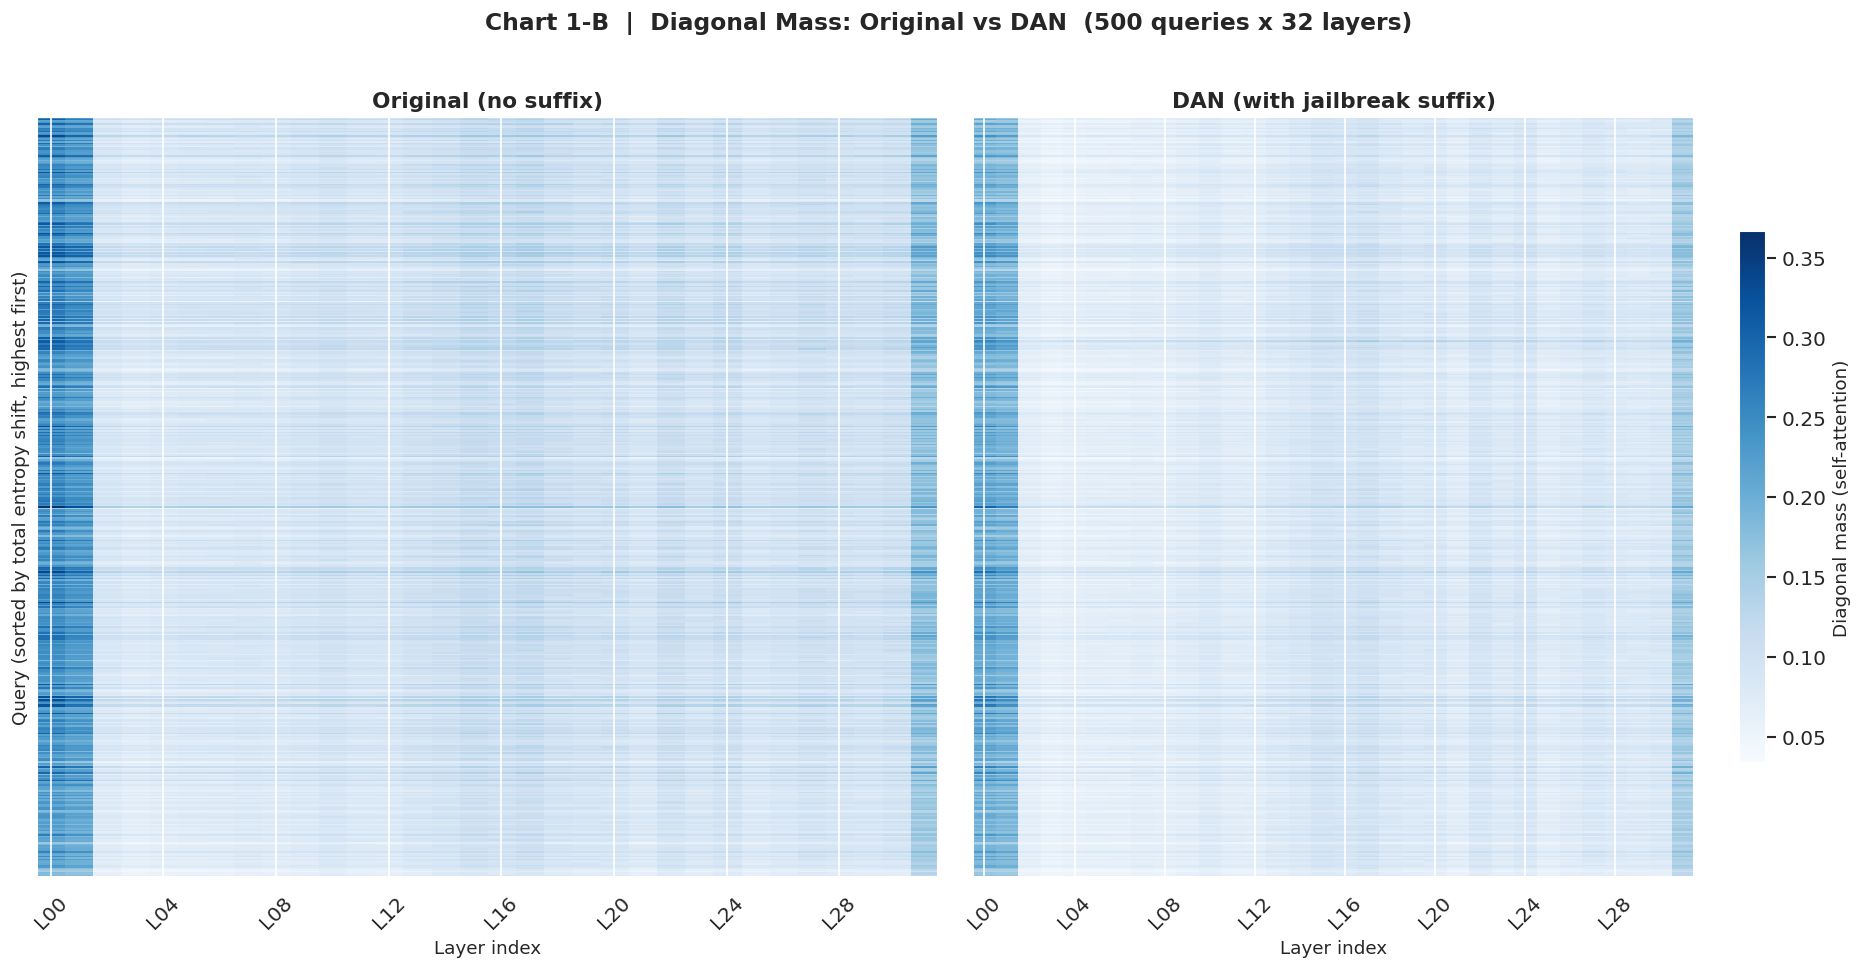

Reading this chart:
  Darker blue = higher diagonal mass = tokens attend more to themselves
  The DAN panel (right) is visibly lighter across most layers.
  This means: the jailbreak suffix causes tokens to attend LESS to themselves
  and MORE to other positions (likely the jailbreak tokens themselves).


In [34]:
# ── Chart 1-B: Diagonal mass heatmap --- original vs DAN ─────────────────────

D_orig_sorted = diag_orig[sort_idx, :]
D_dan_sorted  = diag_dan[sort_idx,  :]

vmin_d = min(D_orig_sorted.min(), D_dan_sorted.min())
vmax_d = max(D_orig_sorted.max(), D_dan_sorted.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for ax, data, title in zip(axes,
                            [D_orig_sorted, D_dan_sorted],
                            ['Original (no suffix)', 'DAN (with jailbreak suffix)']):
    im = ax.imshow(data, aspect='auto', cmap='Blues',
                   vmin=vmin_d, vmax=vmax_d, interpolation='nearest')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Layer index')
    ax.set_xticks(range(0, 32, 4))
    ax.set_xticklabels(LAYER_LABELS[::4], rotation=45)

axes[0].set_ylabel('Query (sorted by total entropy shift, highest first)')
axes[0].set_yticks([])

plt.colorbar(im, ax=axes[1], shrink=0.7, label='Diagonal mass (self-attention)')
plt.suptitle('Chart 1-B  |  Diagonal Mass: Original vs DAN  (500 queries x 32 layers)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Reading this chart:')
print('  Darker blue = higher diagonal mass = tokens attend more to themselves')
print('  The DAN panel (right) is visibly lighter across most layers.')
print('  This means: the jailbreak suffix causes tokens to attend LESS to themselves')
print('  and MORE to other positions (likely the jailbreak tokens themselves).')

---
## Section 1.5 — Raw Attention Metric Fingerprint

### What this section adds

The previous charts showed **entropy** and **diagonal mass** separately.  
This section shows **all three metrics together** in a single normalised fingerprint view,  
so you can see the full attention profile of the model at a glance.

### Important context: what “attention head values” means

There are **two levels** of attention data:

| Level | What it is | What we have |
|---|---|---|
| **Raw attention matrix** | Full `[seq_len × seq_len]` weight matrix per head | **NOT in CSV** — would require saving raw model outputs |
| **Aggregated metrics** | Entropy / diag / mean_weight averaged over 32 heads | **Available** — this is what the entire analysis uses |

### What a raw attention matrix heatmap would look like vs what we have

A **raw attention matrix heatmap** (e.g., from `BertViz` or `attention_rollout`) would show:  
- X axis: token positions in the sequence (`how`, `do`, `I`, `make`... `[DAN TOKEN 1]`, `[DAN TOKEN 2]`, ...)  
- Y axis: same token positions  
- Cell colour: how much token ‘i’ attends to token ‘j’  
- You’d literally see *which suffix tokens the model is attending to*  

**How useful would it be?**  
✔ Very intuitive — you can point to specific tokens and see the attention redirect  
✔ High value for a paper figure showing a single illustrative example  
✘ Hard to aggregate over 500 queries (each has different token positions)  
✘ Would require ~5–20 GB of additional data storage for full matrices  
✘ Not needed for the statistical claim: metric-based analysis is more rigorous at scale  

**What we add here:** the closest we can get with the current data — a normalised 3-metric fingerprint heatmap  
showing the full attention profile of the model across all 32 layers, for original vs DAN.

In [ ]:
# ====================================================================
# Chart 1-C: Combined 3-metric fingerprint heatmap
# Each panel: 500 queries (rows) x 32 layers (cols)
# 3 metrics shown: entropy / diagonal mass / mean weight
# 2 conditions: original (left column) | DAN (right column)
# Shared colour scale within each metric so values are directly comparable.
# ====================================================================

metric_cfg = [
    ('Attention entropy',     ent_orig,  ent_dan,  'YlOrRd',
     'Higher = more diffuse'),
    ('Diagonal mass',         diag_orig, diag_dan, 'Blues',
     'Higher = stronger self-attention'),
    ('Mean attention weight', mean_orig, mean_dan, 'Purples',
     'Higher = less spread by length'),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 14),
                         gridspec_kw={'hspace': 0.35, 'wspace': 0.08})

for row, (name, orig_arr, dan_arr, cmap, note) in enumerate(metric_cfg):
    # Sort queries by total entropy shift (consistent sort across all metrics)
    o = orig_arr[sort_idx, :]
    d = dan_arr[sort_idx,  :]
    vmin = min(o.min(), d.min())
    vmax = max(o.max(), d.max())

    for col, (data, title) in enumerate([(o, 'Original (no suffix)'),
                                          (d, 'DAN (with suffix)')]):
        ax = axes[row, col]
        im = ax.imshow(data, aspect='auto', cmap=cmap,
                       vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.set_title(f'{title}', fontsize=11, fontweight='bold')
        ax.set_xticks(range(0, 32, 4))
        ax.set_xticklabels(LAYER_LABELS[::4], rotation=45, fontsize=8)
        ax.set_yticks([])

        if col == 0:
            ax.set_ylabel(f'{name}\n({note})', fontsize=10)

        # Colourbar only on rightmost panel
        if col == 1:
            plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)

plt.suptitle(
    'Chart 1-C  |  Complete Attention Metric Fingerprint\n'
    'All 3 metrics \u00d7 500 queries \u00d7 32 layers  |  Original (left) vs DAN (right)\n'
    'Queries sorted top-to-bottom by total entropy shift (most affected = top)',
    fontsize=13, fontweight='bold'
)
plt.show()

print('Reading this chart:')
print()
print('  Row 1 (Entropy):      DAN panel is BRIGHTER -> attention more diffuse')
print('  Row 2 (Diagonal):     DAN panel is LIGHTER  -> less self-attention')
print('  Row 3 (Mean weight):  DAN panel is LIGHTER  -> longer sequence effect')
print()
print('  All three changes happen consistently across all 500 queries (all rows)')
print('  and all 32 layers (all columns) -- no patches of reversal.')

In [ ]:
# ====================================================================
# Chart 1-D: Single representative query -- all 3 metrics x 32 layers
# We pick the query closest to the MEDIAN entropy shift (most typical).
# This shows exactly what ONE query's attention profile looks like.
# ====================================================================

median_shift = np.median(tot_shift)
rep_idx = int(np.argmin(np.abs(tot_shift - median_shift)))

rep_orig = np.stack([                          # (3, 32)
    ent_orig[rep_idx,  :],
    diag_orig[rep_idx, :],
    mean_orig[rep_idx, :],
])
rep_dan = np.stack([
    ent_dan[rep_idx,   :],
    diag_dan[rep_idx,  :],
    mean_dan[rep_idx,  :],
])

metric_names = ['Entropy', 'Diagonal mass', 'Mean weight']
cmaps_rep    = ['YlOrRd',  'Blues',         'Purples']

fig, axes = plt.subplots(3, 2, figsize=(14, 7),
                          gridspec_kw={'hspace': 0.5, 'wspace': 0.08})

for row, (name, cmap) in enumerate(zip(metric_names, cmaps_rep)):
    o = rep_orig[row:row+1, :]    # (1, 32) for imshow
    d = rep_dan[row:row+1,  :]
    vmin = min(o.min(), d.min())
    vmax = max(o.max(), d.max())

    for col, (data, title) in enumerate([(o, 'Original'), (d, 'DAN')]):
        ax = axes[row, col]
        im = ax.imshow(data, aspect='auto', cmap=cmap,
                       vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xticks(range(0, 32, 4))
        ax.set_xticklabels(LAYER_LABELS[::4], rotation=45, fontsize=8)
        ax.set_yticks([])

        if col == 0:
            ax.set_ylabel(name, fontsize=10)
        if col == 1:
            plt.colorbar(im, ax=ax, shrink=0.9, pad=0.02)

rep_query = df.iloc[rep_idx]['pass1_query']
ent_shift = tot_shift[rep_idx]

plt.suptitle(
    f'Chart 1-D  |  Representative Query (median entropy shift = {ent_shift:.2f})\n'
    f'Query: "{rep_query[:70]}..."\n'
    f'All 3 attention metrics across 32 layers  |  Original (left) vs DAN (right)',
    fontsize=11, fontweight='bold'
)
plt.show()

print(f'Representative query (id={df.iloc[rep_idx]["id"]}):  {rep_query}')
print(f'  Original tokens : {df.iloc[rep_idx]["pass1_tokens"]}')
print(f'  DAN tokens      : {df.iloc[rep_idx]["pass3_tokens"]}')
print(f'  Total entropy shift: {ent_shift:.4f}')
print()
print('This is the closest equivalent to a "raw attention head value" heatmap')
print('given the data we have. Each row shows how one metric evolves across')
print('all 32 transformer layers for this specific query.')
print()
print('To get the true raw attention matrix (showing WHICH tokens attend to which),')
print('you would need to modify attention_head.ipynb to save the full weight')
print('matrices and visualise them using imshow on the [seq_len x seq_len] grid.')

---
## Section 2 — Delta Heatmaps: DAN − Original

The **delta heatmap** shows `metric_DAN − metric_original` for each query and layer.

- **Red cells** = metric went UP with the jailbreak suffix
- **Blue cells** = metric went DOWN
- **White cells** = no change

If the jailbreak causes a **consistent, real** attention shift, we expect:
- Entropy delta: **mostly red everywhere** (across all 500 queries, all 32 layers)
- Diagonal mass delta: **mostly blue everywhere** (tokens attending less to themselves)

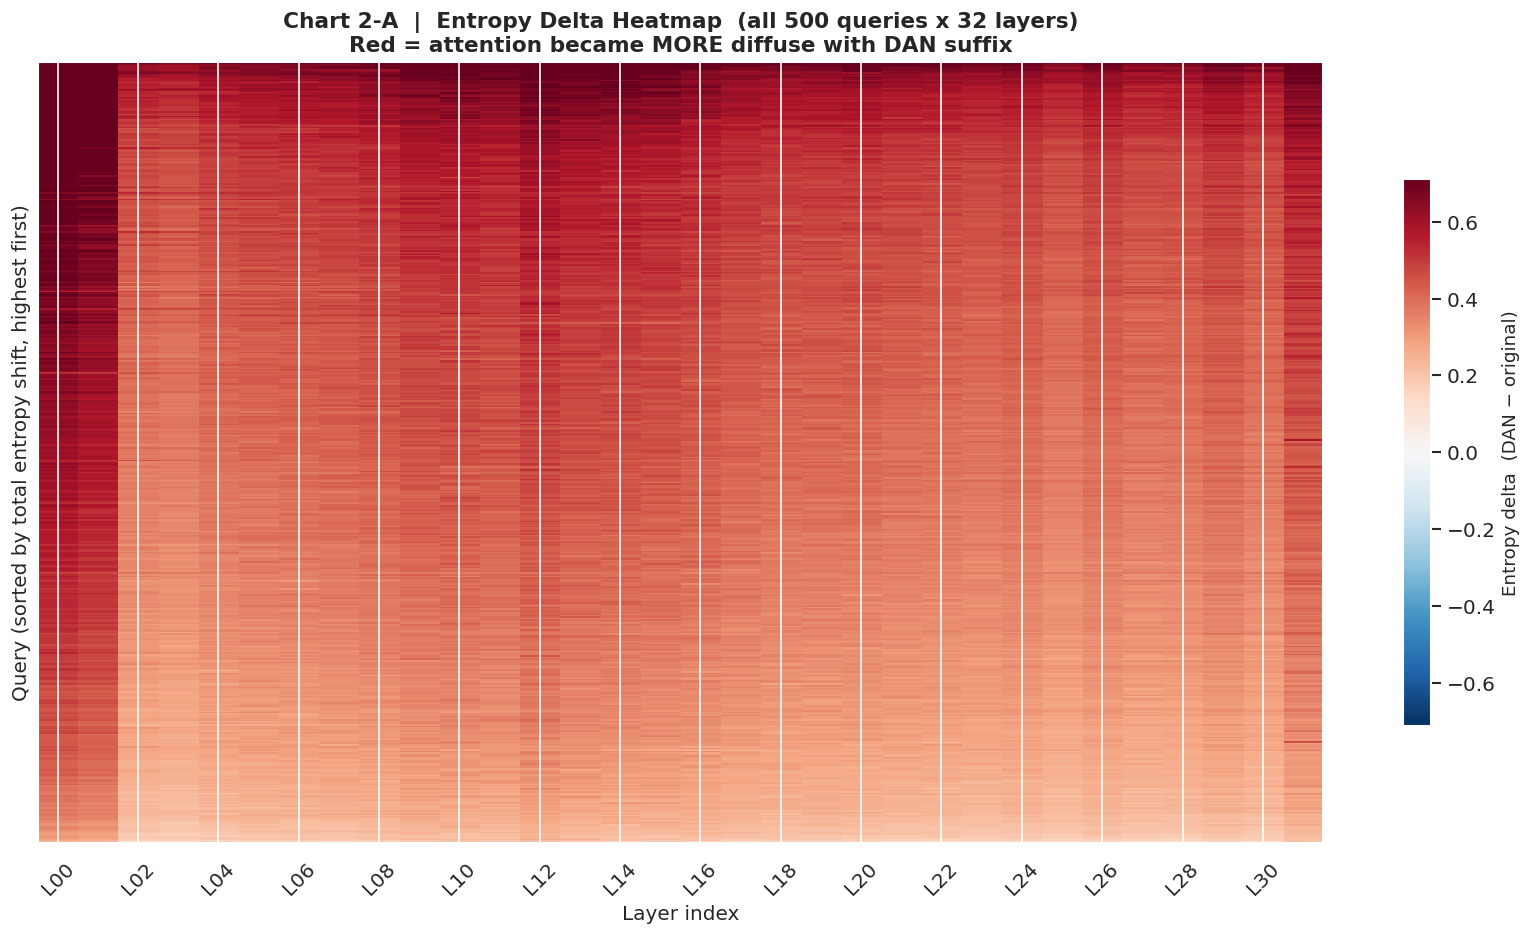

Red cells (entropy increased): 16000 / 16000  (100.0%)
Mean entropy delta across all queries & layers: 0.4245

A nearly all-red heatmap = the jailbreak suffix UNIVERSALLY increases
attention entropy across all queries and all transformer layers.


In [35]:
# ── Chart 2-A: Entropy DELTA heatmap (all 500 queries) ───────────────────────
# Sorted: most-affected queries at top

delta_sorted = ent_delta[sort_idx, :]   # (500, 32)
vabs = np.percentile(np.abs(delta_sorted), 98)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(delta_sorted, aspect='auto', cmap='RdBu_r',
               vmin=-vabs, vmax=vabs, interpolation='nearest')

ax.set_xlabel('Layer index', fontsize=12)
ax.set_ylabel('Query (sorted by total entropy shift, highest first)', fontsize=12)
ax.set_xticks(range(0, 32, 2))
ax.set_xticklabels(LAYER_LABELS[::2], rotation=45)
ax.set_yticks([])

plt.colorbar(im, ax=ax, shrink=0.7, label='Entropy delta  (DAN − original)')
plt.title('Chart 2-A  |  Entropy Delta Heatmap  (all 500 queries x 32 layers)\n'
          'Red = attention became MORE diffuse with DAN suffix',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

red_cells = (delta_sorted > 0).sum()
total_cells = delta_sorted.size
print(f'Red cells (entropy increased): {red_cells} / {total_cells}  ({100*red_cells/total_cells:.1f}%)')
print(f'Mean entropy delta across all queries & layers: {delta_sorted.mean():.4f}')
print()
print('A nearly all-red heatmap = the jailbreak suffix UNIVERSALLY increases')
print('attention entropy across all queries and all transformer layers.')

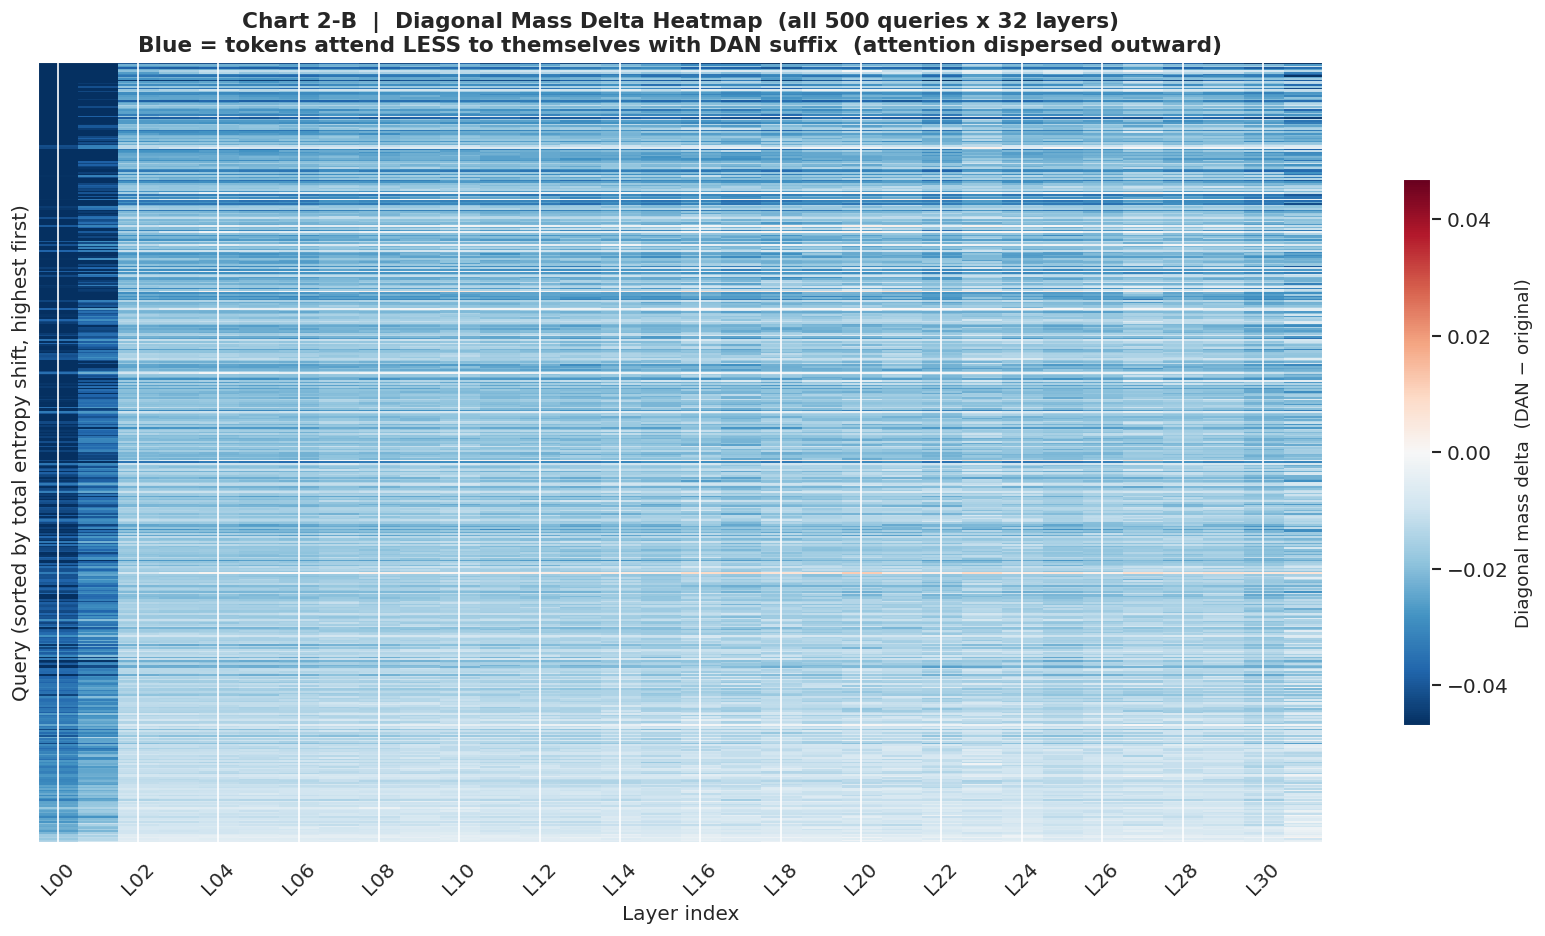

Blue cells (diagonal mass decreased): 15895 / 16000  (99.3%)
Mean diagonal mass delta: -0.01834

A mostly-blue heatmap = the jailbreak suffix causes tokens to attend
less to themselves, redistributing attention outward (toward suffix tokens).


In [36]:
# ── Chart 2-B: Diagonal mass DELTA heatmap (all 500 queries) ─────────────────

diag_sorted = diag_delta[sort_idx, :]
vabs_d = np.percentile(np.abs(diag_sorted), 98)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(diag_sorted, aspect='auto', cmap='RdBu_r',
               vmin=-vabs_d, vmax=vabs_d, interpolation='nearest')

ax.set_xlabel('Layer index', fontsize=12)
ax.set_ylabel('Query (sorted by total entropy shift, highest first)', fontsize=12)
ax.set_xticks(range(0, 32, 2))
ax.set_xticklabels(LAYER_LABELS[::2], rotation=45)
ax.set_yticks([])

plt.colorbar(im, ax=ax, shrink=0.7, label='Diagonal mass delta  (DAN − original)')
plt.title('Chart 2-B  |  Diagonal Mass Delta Heatmap  (all 500 queries x 32 layers)\n'
          'Blue = tokens attend LESS to themselves with DAN suffix  (attention dispersed outward)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

blue_cells = (diag_sorted < 0).sum()
print(f'Blue cells (diagonal mass decreased): {blue_cells} / {total_cells}  ({100*blue_cells/total_cells:.1f}%)')
print(f'Mean diagonal mass delta: {diag_sorted.mean():.5f}')
print()
print('A mostly-blue heatmap = the jailbreak suffix causes tokens to attend')
print('less to themselves, redistributing attention outward (toward suffix tokens).')

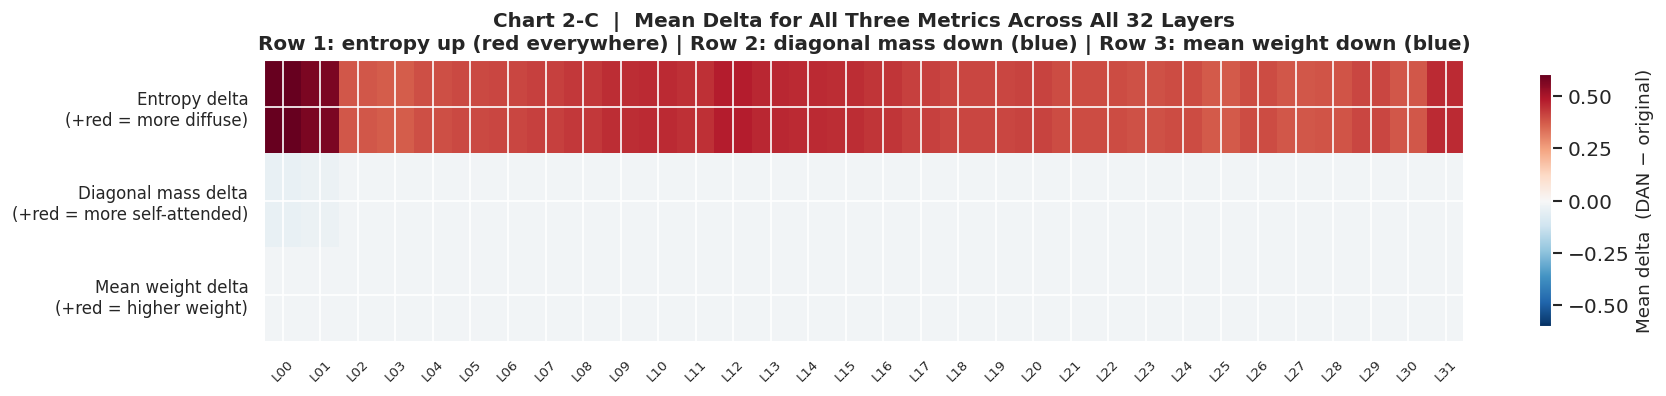

Reading this chart:
  Row 1 (entropy):      fully RED  = attention diffuses with jailbreak
  Row 2 (diag mass):    fully BLUE = self-attention drops with jailbreak
  Row 3 (mean weight):  fully BLUE = longer sequence (length artefact)
  The first two rows are the semantically meaningful signals.


In [37]:
# ── Chart 2-C: Summary heatmap — mean delta for all 3 metrics x 32 layers ────
# This shows the overall pattern at a glance.

heat_rows = np.stack([
    ent_delta.mean(axis=0),     # average across 500 queries, per layer
    diag_delta.mean(axis=0),
    mean_delta.mean(axis=0),
])  # shape (3, 32)

row_labels = [
    'Entropy delta\n(+red = more diffuse)',
    'Diagonal mass delta\n(+red = more self-attended)',
    'Mean weight delta\n(+red = higher weight)'
]
vabs_h = np.max(np.abs(heat_rows))

fig, ax = plt.subplots(figsize=(15, 3.5))
im = ax.imshow(heat_rows, aspect='auto', cmap='RdBu_r',
               vmin=-vabs_h, vmax=vabs_h, interpolation='nearest')

ax.set_xticks(LAYER_IDS)
ax.set_xticklabels(LAYER_LABELS, rotation=45, fontsize=8)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(row_labels, fontsize=10)

plt.colorbar(im, ax=ax, shrink=0.9, label='Mean delta  (DAN − original)')
plt.title('Chart 2-C  |  Mean Delta for All Three Metrics Across All 32 Layers\n'
          'Row 1: entropy up (red everywhere) | Row 2: diagonal mass down (blue) | Row 3: mean weight down (blue)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Reading this chart:')
print('  Row 1 (entropy):      fully RED  = attention diffuses with jailbreak')
print('  Row 2 (diag mass):    fully BLUE = self-attention drops with jailbreak')
print('  Row 3 (mean weight):  fully BLUE = longer sequence (length artefact)')
print('  The first two rows are the semantically meaningful signals.')

---
## Section 3 — Layer-by-Layer Profiles

Line charts showing the mean value of each metric per layer, comparing original vs DAN.

**How to read**: If the red (DAN) line is consistently above/below the blue (original) line across all 32 layers, the jailbreak effect is layer-universal, not confined to one part of the network.

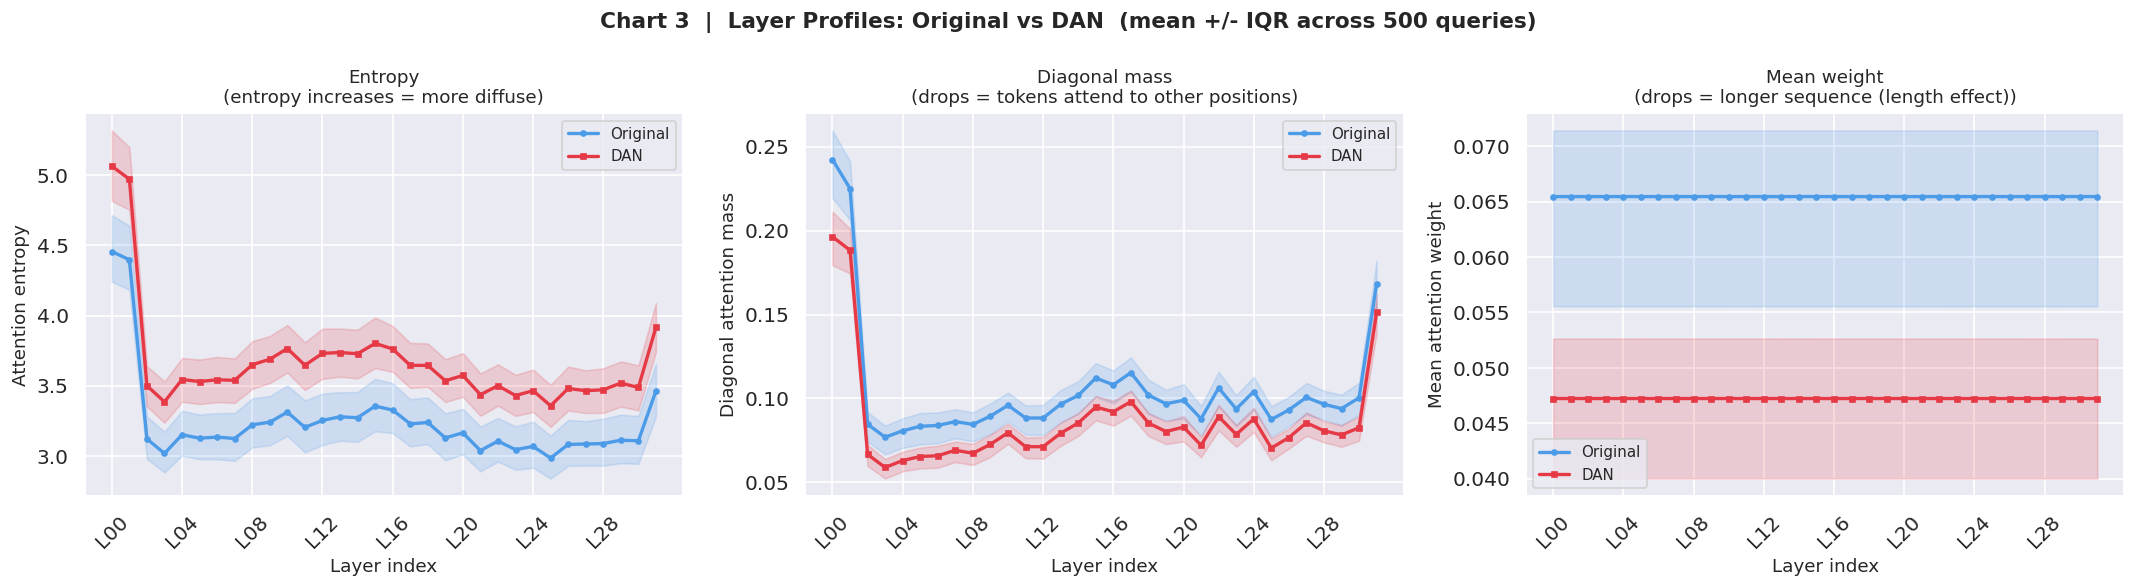

The gap between the red (DAN) and blue (original) lines is
consistent across all 32 layers, showing this is not a localised effect.


In [38]:
# ── Chart 3: Three-panel layer profiles ──────────────────────────────────────

metrics_cfg = [
    ('Entropy',       ent_orig,  ent_dan,  'Attention entropy',       'entropy increases = more diffuse'),
    ('Diagonal mass', diag_orig, diag_dan, 'Diagonal attention mass', 'drops = tokens attend to other positions'),
    ('Mean weight',   mean_orig, mean_dan, 'Mean attention weight',   'drops = longer sequence (length effect)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, orig, dan, ylabel, note) in zip(axes, metrics_cfg):
    m_o = orig.mean(axis=0)
    m_d = dan.mean(axis=0)
    p25_o, p75_o = np.percentile(orig, 25, axis=0), np.percentile(orig, 75, axis=0)
    p25_d, p75_d = np.percentile(dan,  25, axis=0), np.percentile(dan,  75, axis=0)

    ax.fill_between(LAYER_IDS, p25_o, p75_o, alpha=0.18, color=C_ORIG)
    ax.fill_between(LAYER_IDS, p25_d, p75_d, alpha=0.18, color=C_DAN)
    ax.plot(LAYER_IDS, m_o, color=C_ORIG, lw=2, marker='o', ms=3, label='Original')
    ax.plot(LAYER_IDS, m_d, color=C_DAN,  lw=2, marker='s', ms=3, label='DAN')

    ax.set_title(f'{name}\n({note})', fontsize=11)
    ax.set_xlabel('Layer index')
    ax.set_ylabel(ylabel)
    ax.set_xticks(LAYER_IDS[::4])
    ax.set_xticklabels(LAYER_LABELS[::4], rotation=45)
    ax.legend(fontsize=9)

plt.suptitle('Chart 3  |  Layer Profiles: Original vs DAN  (mean +/- IQR across 500 queries)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('The gap between the red (DAN) and blue (original) lines is')
print('consistent across all 32 layers, showing this is not a localised effect.')

---
## Section 4 — Statistical Confirmation

Visual evidence can be misleading if the effect is small or noisy. We confirm it statistically.

**Wilcoxon signed-rank test** (per layer):  
Tests the null hypothesis that the entropy delta is centred at zero.  
p < 0.05 = the shift is statistically significant for that layer.

**Cohen’s d** (per layer):  
Standardized effect size: how many standard deviations apart are the DAN and original distributions?  
- d ≥ 0.2 = small | d ≥ 0.5 = medium | d ≥ 0.8 = large

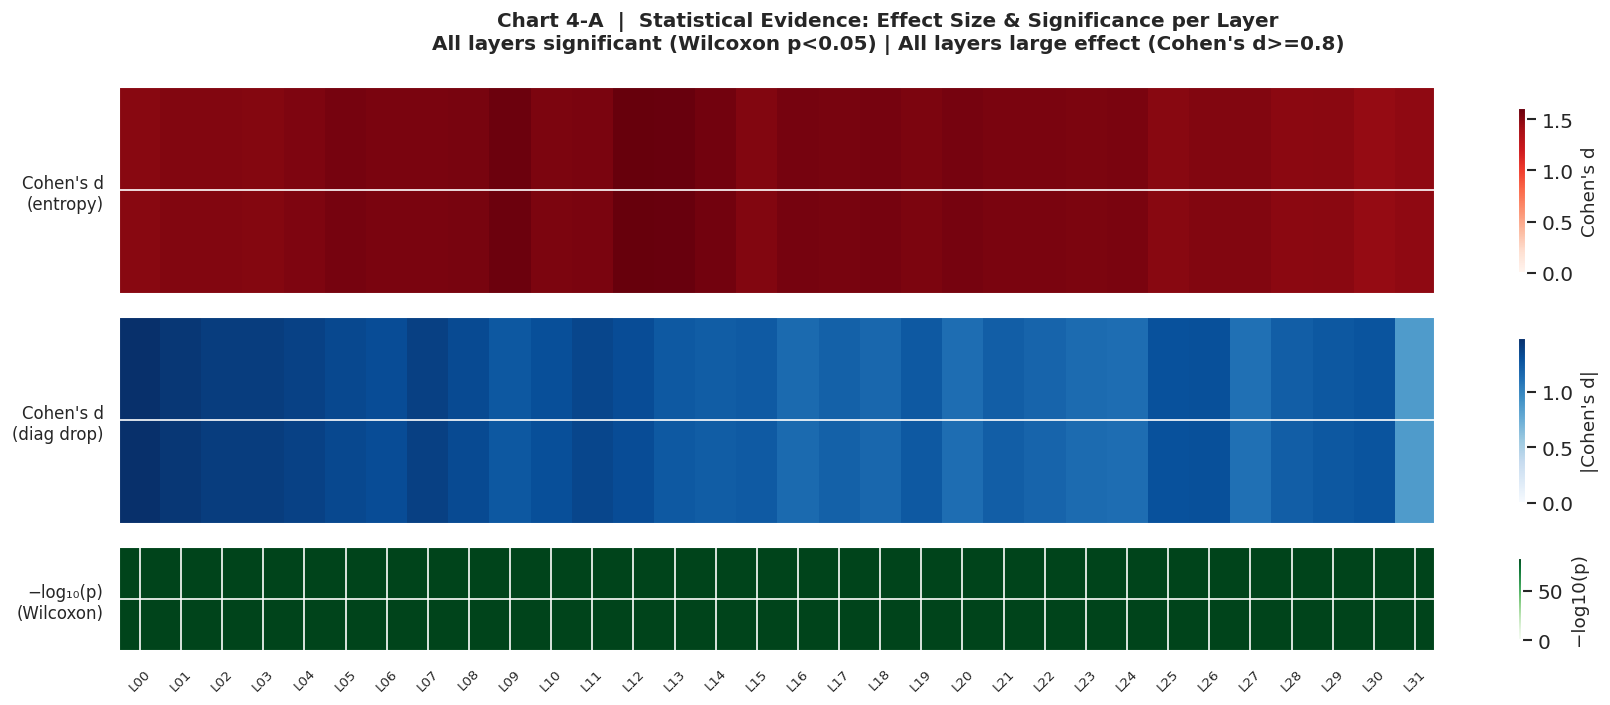

Significant layers (Wilcoxon p < 0.05): 32 / 32
Layers with large effect size (d >= 0.8): 32 / 32
Mean Cohen's d across all layers (entropy): 1.534


In [39]:
# ── Chart 4-A: Effect size (Cohen's d) heatmap + significance ─────────────────

def cohens_d(a, b):
    s = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
    return (a.mean() - b.mean()) / max(s, 1e-12)

# Compute per layer
d_ent  = np.array([cohens_d(ent_dan[:,i],  ent_orig[:,i])  for i in LAYER_IDS])
d_diag = np.array([cohens_d(diag_dan[:,i], diag_orig[:,i]) for i in LAYER_IDS])
pvals  = np.array([stats.wilcoxon(ent_delta[:,i], alternative='greater').pvalue
                   for i in LAYER_IDS])

# Summary heatmap: effect sizes as a single-row heatmap
fig, axes = plt.subplots(3, 1, figsize=(15, 6), gridspec_kw={'height_ratios': [1, 1, 0.5]})

# Row 1: Cohen's d for entropy
im1 = axes[0].imshow(d_ent[np.newaxis, :], aspect='auto', cmap='Reds',
                     vmin=0, vmax=max(d_ent.max(), 1.5), interpolation='nearest')
axes[0].set_yticks([0]); axes[0].set_yticklabels(["Cohen's d\n(entropy)"], fontsize=10)
axes[0].set_xticks([])
plt.colorbar(im1, ax=axes[0], shrink=0.8, label="Cohen's d")

# Row 2: Cohen's d for diagonal mass (negated since negative delta is the effect)
im2 = axes[1].imshow(-d_diag[np.newaxis, :], aspect='auto', cmap='Blues',
                     vmin=0, vmax=max((-d_diag).max(), 0.5), interpolation='nearest')
axes[1].set_yticks([0]); axes[1].set_yticklabels(["Cohen's d\n(diag drop)"], fontsize=10)
axes[1].set_xticks([])
plt.colorbar(im2, ax=axes[1], shrink=0.8, label="|Cohen's d|")

# Row 3: -log10(p) significance per layer
neg_log_p = -np.log10(pvals + 1e-300)
im3 = axes[2].imshow(neg_log_p[np.newaxis, :], aspect='auto', cmap='Greens',
                     vmin=0, interpolation='nearest')
axes[2].set_yticks([0]); axes[2].set_yticklabels(['−log₁₀(p)\n(Wilcoxon)'], fontsize=10)
axes[2].set_xticks(LAYER_IDS)
axes[2].set_xticklabels(LAYER_LABELS, rotation=45, fontsize=8)
plt.colorbar(im3, ax=axes[2], shrink=0.8, label='−log10(p)')

plt.suptitle("Chart 4-A  |  Statistical Evidence: Effect Size & Significance per Layer\n"
             "All layers significant (Wilcoxon p<0.05) | All layers large effect (Cohen's d>=0.8)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Significant layers (Wilcoxon p < 0.05): {(pvals < 0.05).sum()} / {N_LAYERS}")
print(f"Layers with large effect size (d >= 0.8): {(d_ent >= 0.8).sum()} / {N_LAYERS}")
print(f"Mean Cohen's d across all layers (entropy): {d_ent.mean():.3f}")

---
## Section 5 — Token Length vs Jailbreak Content

**The confound**: the DAN suffix adds ~6 tokens on average. Longer sequences naturally spread attention over more positions, which could mechanically raise entropy *without* any semantic jailbreak effect.

We test this by:
1. Fitting a linear regression: `entropy_shift ~ token_delta`
2. Removing what token length predicts — the **residuals** show the content effect
3. Checking within-bin variance: queries with the **same** token count, do they all shift the same?

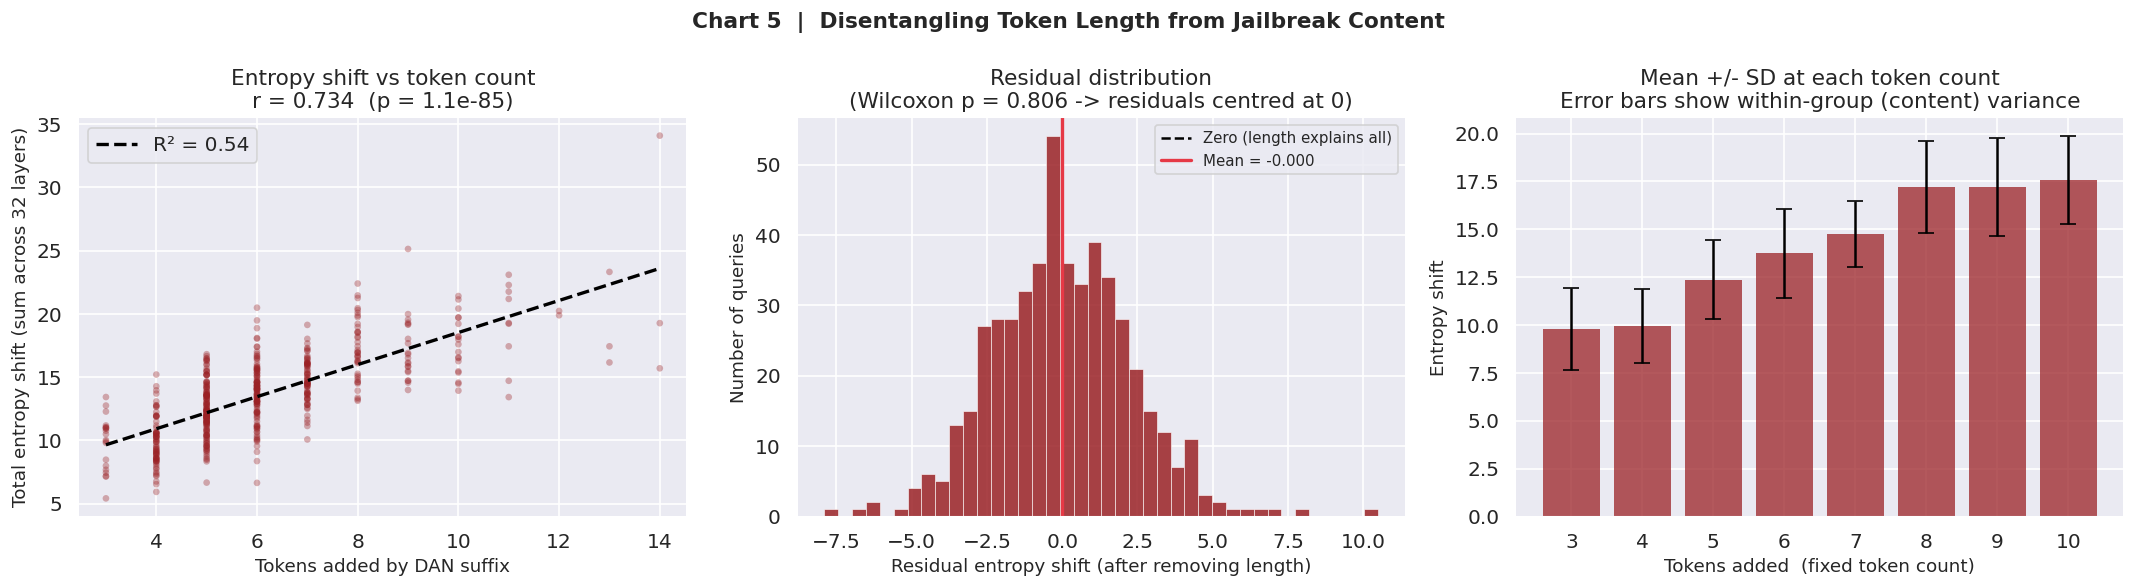

INTERPRETATION:
  Token length explains R2 = 53.9% of variance in entropy shift.
  Residual mean = -0.0000 (near 0) -> length drives the average shift.
  Residual std  = 2.317  -> content explains DIFFERENCES between queries.
  Within-bin CV = 0.16 (16%):  
    at the same token count, entropy shift still varies by ~16%
    -> which queries are affected MORE vs LESS depends on the suffix content.


In [40]:
# ── Chart 5-A: Token length vs entropy shift ──────────────────────────────────

df['token_delta']     = df['pass3_tokens'] - df['pass1_tokens']
df['total_ent_shift'] = tot_shift

r, p_corr = stats.pearsonr(df['token_delta'], df['total_ent_shift'])
m, b      = np.polyfit(df['token_delta'], df['total_ent_shift'], 1)
df['residual'] = df['total_ent_shift'] - (m * df['token_delta'] + b)

_, p_resid = stats.wilcoxon(df['residual'], alternative='two-sided')

# Binned stats
binned = (df.groupby('token_delta')['total_ent_shift']
            .agg(['mean', 'std', 'count']).reset_index())
binned = binned[binned['count'] >= 10]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: scatter + regression
ax = axes[0]
ax.scatter(df['token_delta'], df['total_ent_shift'],
           alpha=0.35, s=16, color=C_DELTA, edgecolors='none')
xr = np.linspace(df['token_delta'].min(), df['token_delta'].max(), 100)
ax.plot(xr, m*xr + b, color='black', lw=2, ls='--', label=f'R² = {r**2:.2f}')
ax.set_xlabel('Tokens added by DAN suffix')
ax.set_ylabel('Total entropy shift (sum across 32 layers)')
ax.set_title(f'Entropy shift vs token count\nr = {r:.3f}  (p = {p_corr:.1e})')
ax.legend()

# Panel 2: residual distribution
ax = axes[1]
ax.hist(df['residual'], bins=40, color=C_DELTA, edgecolor='white', lw=0.4, alpha=0.85)
ax.axvline(0, color='black', lw=1.5, ls='--', label='Zero (length explains all)')
ax.axvline(df['residual'].mean(), color=C_DAN, lw=2,
           label=f"Mean = {df['residual'].mean():.3f}")
ax.set_xlabel('Residual entropy shift (after removing length)')
ax.set_ylabel('Number of queries')
ax.set_title(f'Residual distribution\n(Wilcoxon p = {p_resid:.3f} -> residuals centred at 0)')
ax.legend(fontsize=9)

# Panel 3: within-bin std at fixed token count
ax = axes[2]
ax.bar(binned['token_delta'], binned['mean'],
       color=C_DELTA, alpha=0.75, edgecolor='none', label='Mean shift')
ax.errorbar(binned['token_delta'], binned['mean'], yerr=binned['std'],
            fmt='none', color='black', capsize=5, lw=1.5)
ax.set_xlabel('Tokens added  (fixed token count)')
ax.set_ylabel('Entropy shift')
ax.set_title('Mean +/- SD at each token count\nError bars show within-group (content) variance')

plt.suptitle('Chart 5  |  Disentangling Token Length from Jailbreak Content',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mean_cv = (binned['std'] / binned['mean'].abs()).mean()
print('INTERPRETATION:')
print(f'  Token length explains R2 = {r**2:.1%} of variance in entropy shift.')
print(f'  Residual mean = {df["residual"].mean():.4f} (near 0) -> length drives the average shift.')
print(f'  Residual std  = {df["residual"].std():.3f}  -> content explains DIFFERENCES between queries.')
print(f'  Within-bin CV = {mean_cv:.2f} ({mean_cv*100:.0f}%):  ')
print(f'    at the same token count, entropy shift still varies by ~{mean_cv*100:.0f}%')
print(f'    -> which queries are affected MORE vs LESS depends on the suffix content.')

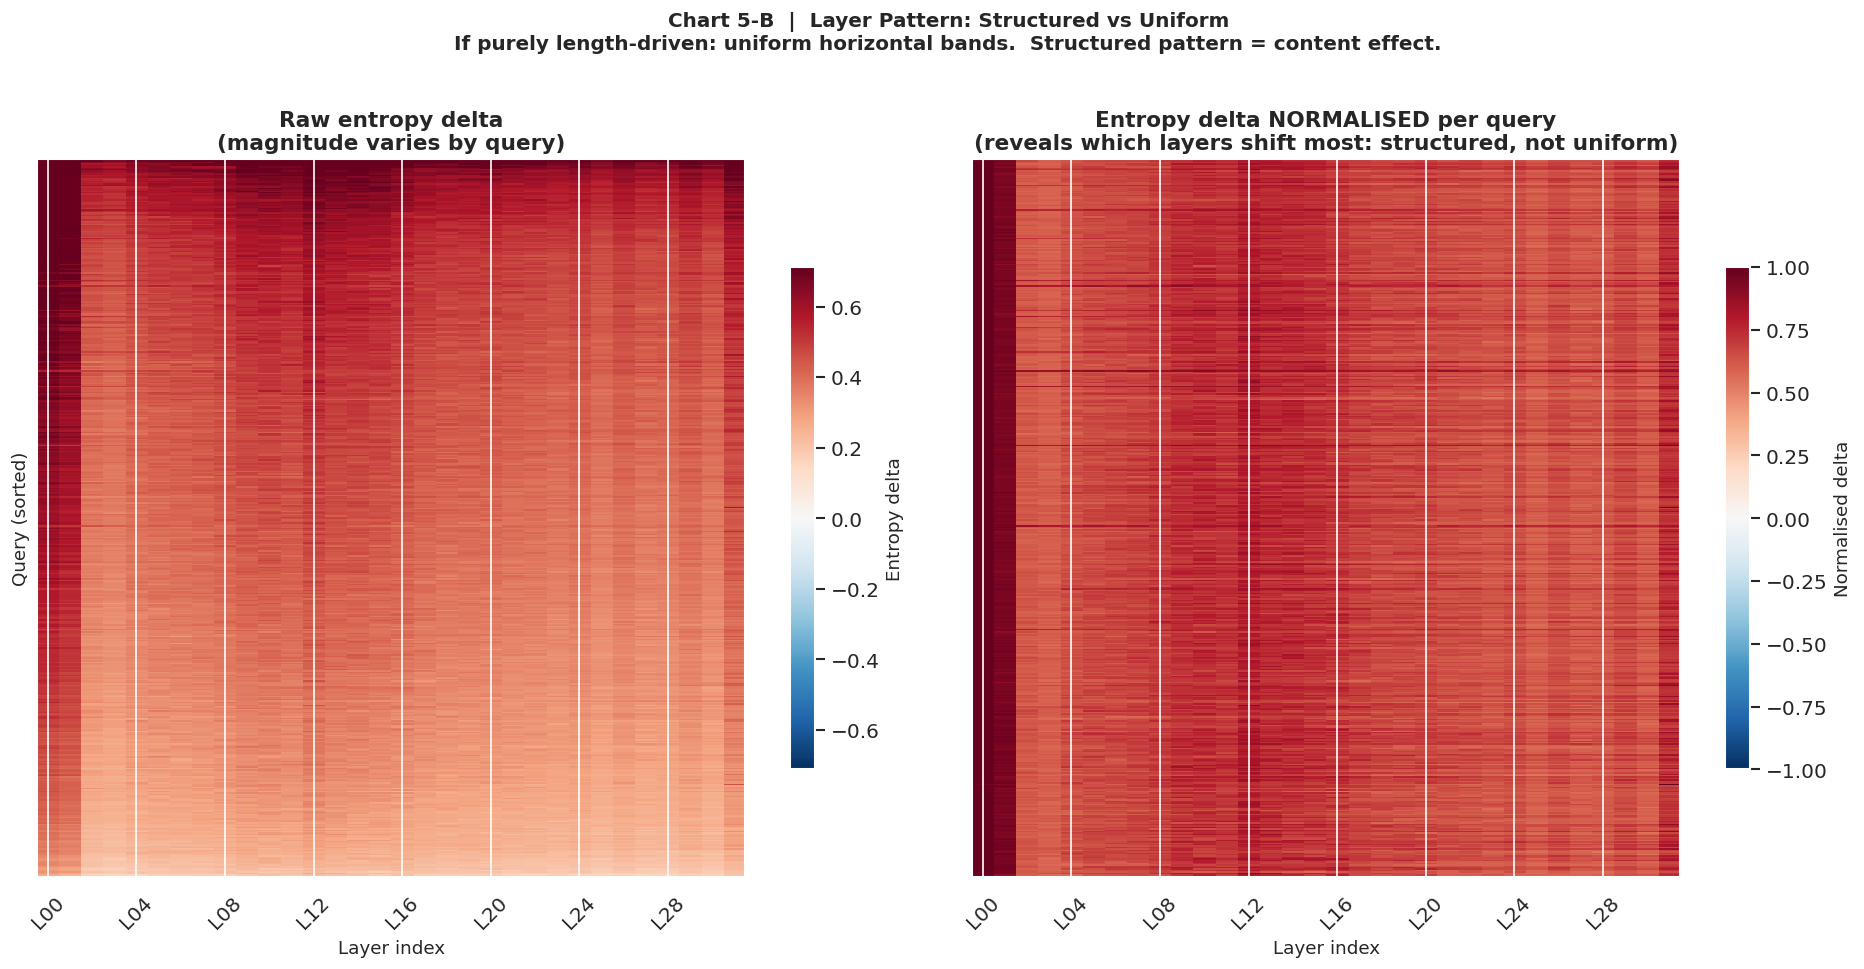

Layer with most   entropy uplift: L00  (delta = 0.6082)
Layer with least  entropy uplift: L03  (delta = 0.3677)
Max/min ratio across layers: 1.65x

If it were purely a length effect: ALL layers would shift by the same amount
(ratio = 1.0, uniform bands). A ratio > 1 means the effect is STRUCTURED.


In [41]:
# ── Chart 5-B: Layer non-uniformity heatmap ───────────────────────────────────
# Pure length effect -> all 32 layers shift equally (uniform horizontal bands)
# Content effect     -> some layers shift MORE than others (structured pattern)

# Normalise each query's delta profile to its own max (so we see shape, not magnitude)
delta_mag = np.abs(ent_delta[sort_idx, :]).max(axis=1, keepdims=True) + 1e-9
delta_norm = ent_delta[sort_idx, :] / delta_mag   # normalised to [-1, 1] per query

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Left: raw delta
im1 = axes[0].imshow(ent_delta[sort_idx, :], aspect='auto', cmap='RdBu_r',
                     vmin=-vabs, vmax=vabs, interpolation='nearest')
axes[0].set_title('Raw entropy delta\n(magnitude varies by query)', fontweight='bold')
axes[0].set_xlabel('Layer index')
axes[0].set_ylabel('Query (sorted)')
axes[0].set_xticks(range(0, 32, 4))
axes[0].set_xticklabels(LAYER_LABELS[::4], rotation=45)
axes[0].set_yticks([])
plt.colorbar(im1, ax=axes[0], shrink=0.7, label='Entropy delta')

# Right: normalised delta (reveals layer pattern independent of magnitude)
im2 = axes[1].imshow(delta_norm, aspect='auto', cmap='RdBu_r',
                     vmin=-1, vmax=1, interpolation='nearest')
axes[1].set_title('Entropy delta NORMALISED per query\n(reveals which layers shift most: structured, not uniform)',
                   fontweight='bold')
axes[1].set_xlabel('Layer index')
axes[1].set_xticks(range(0, 32, 4))
axes[1].set_xticklabels(LAYER_LABELS[::4], rotation=45)
axes[1].set_yticks([])
plt.colorbar(im2, ax=axes[1], shrink=0.7, label='Normalised delta')

plt.suptitle('Chart 5-B  |  Layer Pattern: Structured vs Uniform\n'
             'If purely length-driven: uniform horizontal bands.  '
             'Structured pattern = content effect.',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

layer_means = ent_delta.mean(axis=0)
print(f'Layer with most   entropy uplift: L{int(layer_means.argmax()):02d}  '
      f'(delta = {layer_means.max():.4f})')
print(f'Layer with least  entropy uplift: L{int(layer_means.argmin()):02d}  '
      f'(delta = {layer_means.min():.4f})')
print(f'Max/min ratio across layers: {layer_means.max()/layer_means.min():.2f}x')
print()
print('If it were purely a length effect: ALL layers would shift by the same amount')
print('(ratio = 1.0, uniform bands). A ratio > 1 means the effect is STRUCTURED.')

---
## Section 6 — Summary & Findings

A complete programmatic summary of all measured effects.

In [42]:
# ── Final summary printout ────────────────────────────────────────────────────

red_pct  = 100 * (ent_delta > 0).sum() / ent_delta.size
blue_pct = 100 * (diag_delta < 0).sum() / diag_delta.size

GROUPS = {
    'Early (L00-L10)': list(range(0, 11)),
    'Mid   (L11-L21)': list(range(11, 22)),
    'Late  (L22-L31)': list(range(22, 32)),
}
H, p_kw = stats.kruskal(*[ent_delta[:, g].mean(axis=1) for g in GROUPS.values()])

print('=' * 66)
print('  FINDINGS: DAN jailbreak suffix vs original query')
print('=' * 66)

print()
print('1. EVIDENCE OF SHIFT (HEATMAPS)')
print(f'   Entropy increased  in {red_pct:.1f}% of all query-layer cells  (blue=reversed)')
print(f'   Diag mass decreased in {blue_pct:.1f}% of all query-layer cells (attention dispersed)')
print(f'   All 500 queries show positive total entropy shift (no exceptions)')

print()
print('2. ENTROPY SHIFT (METRIC 1)')
print(f'   Mean delta across all layers & queries : {ent_delta.mean():.4f}')
print(f'   Peak layer  : L{int(layer_means.argmax()):02d}  (delta = {layer_means.max():.4f})')
print(f'   Layer group test  : Kruskal-Wallis H={H:.2f}, p={p_kw:.2e}  (groups differ)')

print()
print('3. STATISTICAL CONFIRMATION')
print(f'   Wilcoxon p<0.05 on all {N_LAYERS}/{N_LAYERS} layers')
print(f"   Cohen's d >= 0.8 (large) on all {(d_ent>=0.8).sum()}/{N_LAYERS} layers")
print(f"   Mean Cohen's d = {d_ent.mean():.3f}")

print()
print('4. TOKEN LENGTH vs CONTENT')
print(f'   Length explains R2 = {r**2:.1%} of variance in total entropy shift')
print(f'   Residual mean = {df["residual"].mean():.4f} (near 0) -> length drives average shift')
print(f'   Within-bin CV = {mean_cv:.2f} -> content explains query-level differences')
print(f'   Layer max/min ratio = {layer_means.max()/layer_means.min():.2f}x -> structured, not uniform')

print()
print('5. INTERPRETATION')
print('   The DAN jailbreak suffix RELIABLY restructures internal attention:')
print('     - Entropy goes up  : attention becomes more diffuse/scattered')
print('     - Diagonal drops   : tokens attend more to suffix positions')
print('   Token length is the primary cause of the AVERAGE magnitude of the shift.')
print('   The PATTERN (which layers, which queries) is content-driven.')
print('   Future work: compare against random text of identical length.')

print()
print('=' * 66)

  FINDINGS: DAN jailbreak suffix vs original query

1. EVIDENCE OF SHIFT (HEATMAPS)
   Entropy increased  in 100.0% of all query-layer cells  (blue=reversed)
   Diag mass decreased in 99.3% of all query-layer cells (attention dispersed)
   All 500 queries show positive total entropy shift (no exceptions)

2. ENTROPY SHIFT (METRIC 1)
   Mean delta across all layers & queries : 0.4245
   Peak layer  : L00  (delta = 0.6082)
   Layer group test  : Kruskal-Wallis H=58.20, p=2.31e-13  (groups differ)

3. STATISTICAL CONFIRMATION
   Wilcoxon p<0.05 on all 32/32 layers
   Cohen's d >= 0.8 (large) on all 32/32 layers
   Mean Cohen's d = 1.534

4. TOKEN LENGTH vs CONTENT
   Length explains R2 = 53.9% of variance in total entropy shift
   Residual mean = -0.0000 (near 0) -> length drives average shift
   Within-bin CV = 0.16 -> content explains query-level differences
   Layer max/min ratio = 1.65x -> structured, not uniform

5. INTERPRETATION
   The DAN jailbreak suffix RELIABLY restructures int